In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import torch
from matplotlib import pyplot as plt

sys.path.insert(0, os.path.abspath("../.."))

from AML_BRATS.data.data_loading import get_dataset_folds, BRATSDataset
from AML_BRATS.models.train_unet import UNet

folds, _ = get_dataset_folds(
    "../../data/BraTS2020_training_data/content/data/meta_data.csv"
)

/home/muslii4/school/by2/AML-BRATS/.venv/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


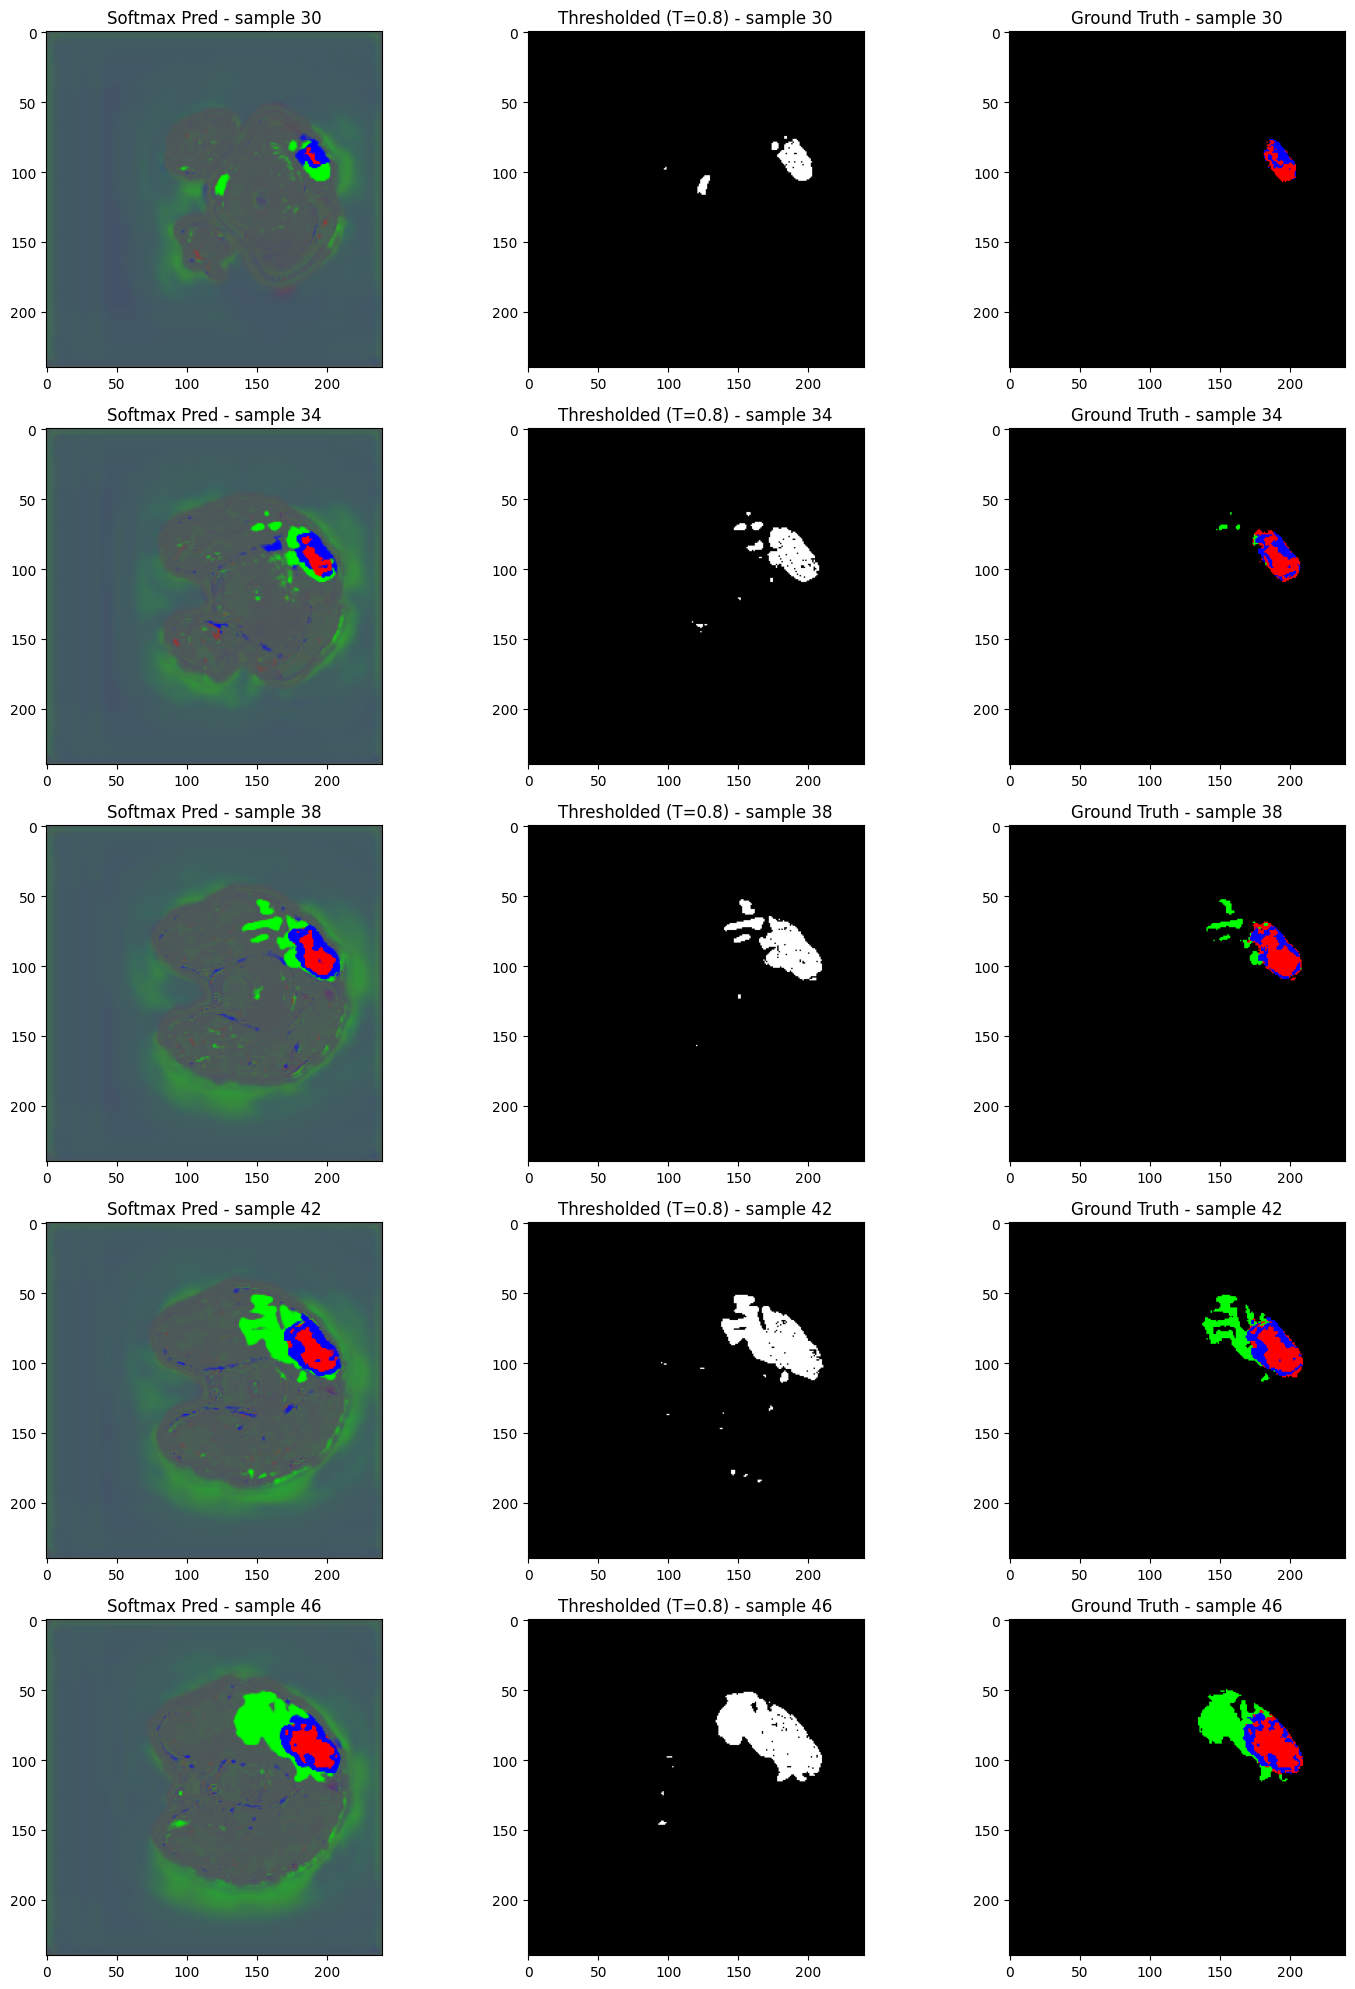

In [ ]:
fold1_val = folds[0][1]
inputs = fold1_val[:]
ds = BRATSDataset(inputs, base_path=Path("../.."))

model = UNet(3, True)
MODEL_NAME = (
    "UNET_HYD_25EPOCHS_adam_BNORM_LR0.0001_WD0.01_bce1_NOAUG_BS64_FOLD1"
)
model.load_state_dict(
    torch.load(f"../../models/{MODEL_NAME}_final.pkl", weights_only=True)
)
model.eval()

sample_indices = [2, 7, 15, 23, 31, 42, 50, 61, 74, 88]
sample_indices = list(range(30, 50, 4))

# Threshold value for binary predictions
THRESHOLD = 0.8

fig, axes = plt.subplots(
    len(sample_indices), 3, figsize=(15, 4 * len(sample_indices))
)

for row, sample_index in enumerate(sample_indices):
    data = ds[sample_index]
    im = torch.from_numpy(data["image"]).unsqueeze(0)
    mask = np.moveaxis(data["mask"], 0, -1)
    with torch.no_grad():
        output = model(im)

    rgb = output[0].softmax(dim=0).permute(1, 2, 0).cpu().numpy()
    
    # Apply thresholding: take max probability across classes and apply threshold
    max_probs = np.max(rgb, axis=2)
    threshold_mask = max_probs > THRESHOLD
    thresholded_rgb = rgb.copy()
    thresholded_rgb[~threshold_mask] = 0  # Set below-threshold pixels to black

    # Display softmax prediction
    axes[row, 0].imshow(rgb[:, :, :])
    axes[row, 0].set_title(f"Softmax Pred - sample {sample_index}")
    
    # Display thresholded prediction with RGB colors
    axes[row, 1].imshow(thresholded_rgb)
    axes[row, 1].set_title(f"Thresholded (T={THRESHOLD}) - sample {sample_index}")

    # Display ground truth mask
    axes[row, 2].imshow(mask)
    axes[row, 2].set_title(f"Ground Truth - sample {sample_index}")

plt.tight_layout()
